In [186]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [187]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [188]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [189]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='drucker_pager.tcl',
                output_file='drucker_pager.tcl.py',
                prefix="ops")

In [190]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (112413811341)>


In [191]:
ops.wipe()
ops.model('BasicBuilder', '-ndm', 3, '-ndf', 3)
ops.node(1, 1.0, 0.0, 0.0)
ops.node(2, 1.0, 1.0, 0.0)
ops.node(3, 0.0, 1.0, 0.0)
ops.node(4, 0.0, 0.0, 0.0)
ops.node(5, 1.0, 0.0, 1.0)
ops.node(6, 1.0, 1.0, 1.0)
ops.node(7, 0.0, 1.0, 1.0)
ops.node(8, 0.0, 0.0, 1.0)
ops.fix(1, 0, 1, 1)
ops.fix(2, 0, 0, 1)
ops.fix(3, 1, 0, 1)
ops.fix(4, 1, 1, 1)
ops.fix(5, 0, 1, 0)
ops.fix(6, 0, 0, 0)
ops.fix(7, 1, 0, 0)
ops.fix(8, 1, 1, 0)
ops.nDMaterial('DruckerPrager', 2, 27777.78, 9259.26, 5.0, 0.398, 0.398, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.7) # 9259.26
ops.element('stdBrick', 1, 1, 2, 3, 4, 5, 6, 7, 8, 2, 0.0, 0.0, 0.0)
print('model Built...')

model Built...


In [192]:
ops.recorder('Node', '-file', 'adisplacements1.out', '-time', '-dT', 0.1, '-nodeRange', 1, 8, '-dof', 1, 2, 3, 'disp')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'astress1.out', '-dT', 0.1, 'material', 2, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'astrain1.out', '-dT', 0.1, 'material', 2, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'astate1.out', '-dT', 0.1, 'material', 2, 'state')

23

In [193]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [194]:
ops.timeSeries('Path', 1, '-time', 0, 10,100, '-values', 0, 1, 1, '-factor', 1)
ops.pattern('Plain', 1, 1)
ops.load(1, -2.5, 0.0, 0.0)
ops.load(2, -2.5, -2.5, 0.0)
ops.load(3, 0.0, -2.5, 0.0)
ops.load(5, -2.5, 0.0, 0.0)
ops.load(6, -2.5, -2.5, 0.0)
ops.load(7, 0.0, -2.5, 0.0)

In [195]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [196]:
ops.timeSeries('Path', 2, '-time', 0, 10,100, '-values', 0, 1, 5, '-factor', 1)
ops.pattern('Plain', 2, 2)
ops.load(5, 0.0, 0.0, -2.5)
ops.load(6, 0.0, 0.0, -2.5)
ops.load(7, 0.0, 0.0, -2.5)
ops.load(8, 0.0, 0.0, -2.5)

In [197]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [198]:
ops.integrator('LoadControl', 0.1)
ops.numberer('RCM',)
ops.system('SparseGeneral',)
ops.constraints('Transformation',)
ops.test('NormDispIncr', 1e-05, 10, 1)
ops.algorithm('Newton',)
ops.analysis('Static',)
print('starting the hydrostatic analysis...')

starting the hydrostatic analysis...


In [199]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
for _ in range(1000):
    ops.analyze(1,)
    ODB.fetch_response_step()
ODB.save_response(zlib=True)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.04083e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 2.08167e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 2.4037e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 2.4037e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.01032e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.11022e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.41526e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 9.61481e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.57009e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [200]:
node_resp = opst.post.get_nodal_responses(odb_tag=1)
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-1.nc ...

<xarray.Dataset> Size: 1MB
Dimensions:             (time: 1001, nodeTags: 8, DOFs: 6)
Coordinates:
  * time                (time) float32 4kB 0.0 0.1 0.2 0.3 ... 96.4 96.4 96.4
  * nodeTags            (nodeTags) int64 64B 1 2 3 4 5 6 7 8
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    vel                 (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    accel               (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    reaction            (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 32kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Dis

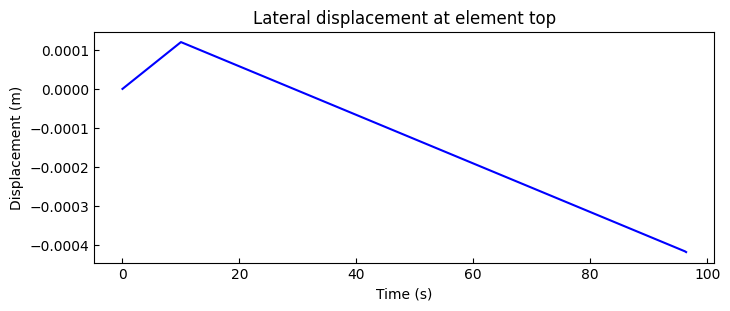

In [201]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UX")
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3 - disp1, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

In [202]:
ele_resp = opst.post.get_element_responses(odb_tag=1, ele_type="Brick")

OPSTOOL ::  Loading Brick response data from .opstool.output/RespStepData-1.nc ...

In [203]:
print("Data Variables in Element Responses:", ele_resp.data_vars)

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 192kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 192kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 192kB 0.0 ......
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 192kB 0.0 ......
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 192kB 0.0 ......
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 192kB 0.0 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 224kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 224kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 224kB 0.0 ... 1...
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 224kB 0.0 ... 0...


In [204]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1) # tr(σ)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1) # s+q kin, where s is the deviatoric stress tensor and q kin is the back-stress tensor
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1) # tr(εp)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1) 
#eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)
print(sigma22)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 8)> Size: 32kB
array([[  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.       ,   0.       ],
       [ -0.1      ,  -0.1      ,  -0.1      , ...,  -0.1      ,
         -0.1      ,  -0.1      ],
       [ -0.2      ,  -0.2      ,  -0.2      , ...,  -0.2      ,
         -0.2      ,  -0.2      ],
       ...,
       [-10.034039 , -10.032049 , -10.030377 , ..., -10.031821 ,
        -10.0315895, -10.033759 ],
       [-10.034039 , -10.032049 , -10.030377 , ..., -10.031821 ,
        -10.0315895, -10.033759 ],
       [-10.034039 , -10.032049 , -10.030377 , ..., -10.031821 ,
        -10.0315895, -10.033759 ]], shape=(1001, 8), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.1 0.2 0.3 0.4 ... 96.4 96.4 96.4 96.4
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 64B 1 2 3 4 5 6 7 8
    stressDOFs   <U7 28B 'sigma22'


In [205]:
eps12_ele1_1 = sigma11.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)


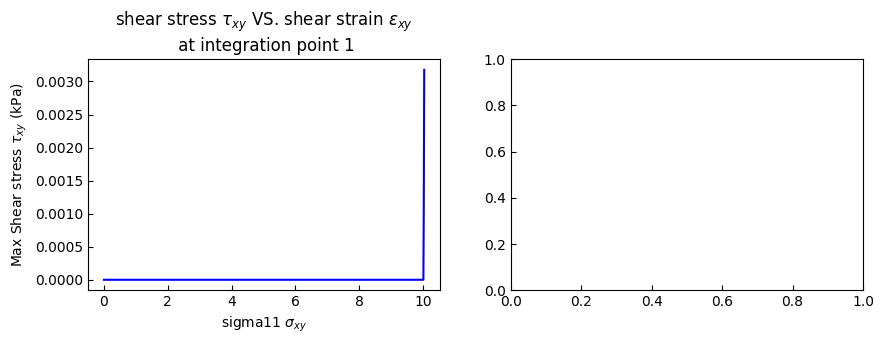

In [206]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(-eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"sigma11 $\sigma_{xy}$")
axs[0].set_ylabel(r"Max Shear stress $\tau_{xy}$ (kPa)")
plt.show()

In [207]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 8)> Size: 32kB
array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-2.7515898e-18, -4.6026596e-18, -6.0034680e-19, ...,
        -8.0046251e-18, -1.0005781e-18, -6.4036994e-18],
       [-4.0023121e-19,  3.2018497e-18,  5.0028907e-19, ...,
         1.6009248e-18,  6.0034684e-18, -3.2018497e-18],
       ...,
       [ 1.8093493e+01, -1.8091623e+01, -1.8093925e+01, ...,
         1.8093845e+01, -1.8090990e+01,  1.8093092e+01],
       [ 1.8093493e+01, -1.8091623e+01, -1.8093925e+01, ...,
         1.8093845e+01, -1.8090990e+01,  1.8093092e+01],
       [ 1.8093493e+01, -1.8091623e+01, -1.8093925e+01, ...,
         1.8093845e+01, -1.8090990e+01,  1.8093092e+01]],
      shape=(1001, 8), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.1 0.2 0.3 0.4 ... 96.4 96.4 96.4 96.4
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 64B 1 2 3 4 5

In [208]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=1)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=1)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=1)

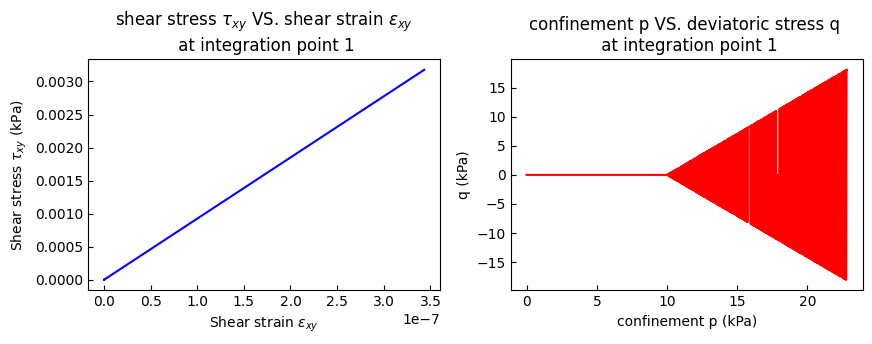

In [209]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [210]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [211]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_stress_strain_abs(stress_file, strain_file):
    """
    Plots absolute stress vs. absolute strain for σₓ, σ_y, and shear
    from given stress and strain files.

    Parameters:
    stress_file (str): Path to the stress data file.
    strain_file (str): Path to the strain data file.
    """
    # Load data
    stress_df = pd.read_csv(stress_file, delim_whitespace=True, header=None)
    strain_df = pd.read_csv(strain_file, delim_whitespace=True, header=None)
    
    # Extract and convert to absolute values
    time_stress = stress_df[0]
    sigma_x = stress_df[1].abs()
    sigma_y = stress_df[2].abs()
    shear = stress_df[3].abs()
    
    time_strain = strain_df[0]
    eps_x = strain_df[1].abs()
    eps_y = strain_df[2].abs()
    shear_strain = strain_df[3].abs()
    
    # Warn if time steps differ
    if not time_stress.equals(time_strain):
        print("Warning: Time steps in stress and strain data do not match exactly.")

    # Plotting
    plt.figure(figsize=(12, 8))
    
    plt.subplot(3, 1, 1)
    plt.plot(eps_x, sigma_x, label='|σₓ| vs |εₓ|')
    plt.xlabel("Strain |εₓ|")
    plt.ylabel("Stress |σₓ|")
    plt.grid(True)
    plt.legend()
    
    plt.subplot(3, 1, 2)
    plt.plot(eps_y, sigma_y, label='|σ_y| vs |ε_y|', color='orange')
    plt.xlabel("Strain |ε_y|")
    plt.ylabel("Stress |σ_y|")
    plt.grid(True)
    plt.legend()
    
    plt.subplot(3, 1, 3)
    plt.plot(shear_strain, shear, label='|Shear Stress| vs |Shear Strain|', color='green')
    plt.xlabel("Shear Strain |γₓᵧ|")
    plt.ylabel("Shear Stress |τₓᵧ|")
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.suptitle("Absolute Stress vs Strain", fontsize=16, y=1.02)
    plt.show()


In [212]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_sigma_x_vs_shear(stress_file):
    """
    Plots absolute τₓᵧ vs. absolute σₓ from a stress data file.

    Parameters:
    stress_file (str): Path to the stress data file.
    """
    # Load the file
    stress_df = pd.read_csv(stress_file, delim_whitespace=True, header=None)

    # Extract and convert to absolute values
    sigma_x = stress_df[1]#.abs()
    shear_xy = stress_df[3].abs()

    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(sigma_x, shear_xy, marker='o', linestyle='-', color='blue', label='|τₓᵧ| vs |σₓ|')
    plt.xlabel('Axial Stress |σₓ|')
    plt.ylabel('Shear Stress |τₓᵧ|')
    plt.title('Shear Stress vs. Axial Stress')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage
# plot_sigma_x_vs_shear("astress1.out")


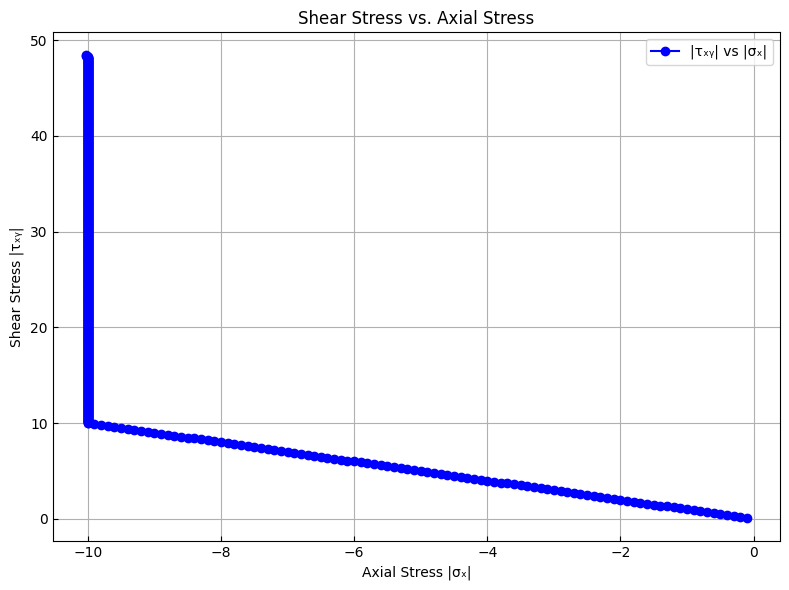

In [213]:
plot_sigma_x_vs_shear("astress1.out")


In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_principal_vs_max_shear(stress_file):
    """
    Computes and plots |σ₁| and |σ₂| against |τ_max| from a stress data file.

    Parameters:
    stress_file (str): Path to the stress data file (whitespace-separated values).
                       Columns:
                       - Column 1: time (ignored)
                       - Column 2: sigma_x
                       - Column 3: sigma_y
                       - Column 4: tau_xy
    """
    # Load the file
    df = pd.read_csv(stress_file, delim_whitespace=True, header=None)

    # Extract stress components
    sigma_x = df[1]
    sigma_y = df[2]
    tau_xy = df[3]

    # Compute center of Mohr’s circle
    avg_sigma = (sigma_x + sigma_y) / 2

    # Compute radius of Mohr’s circle (τ_max)
    radius = np.sqrt(((sigma_x - sigma_y) / 2)**2 + tau_xy**2)

    # Compute principal stresses
    sigma_1 = avg_sigma + radius
    sigma_2 = avg_sigma - radius
    tau_max = radius

    # Plot
    plt.figure(figsize=(8, 6))
    #plt.plot(sigma_1, tau_max, label='|τ_max| vs |σ₁|', marker='o', color='blue')
    plt.plot(sigma_2, tau_max, label='|τ_max| vs |σ₂|', marker='x', color='green')
    plt.xlabel("Principal Stress |σ₁| or |σ₂|")
    plt.ylabel("Maximum Shear Stress |τ_max|")
    plt.title("Principal Stresses vs Maximum Shear Stress")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage
# plot_principal_vs_max_shear("astress1.out")


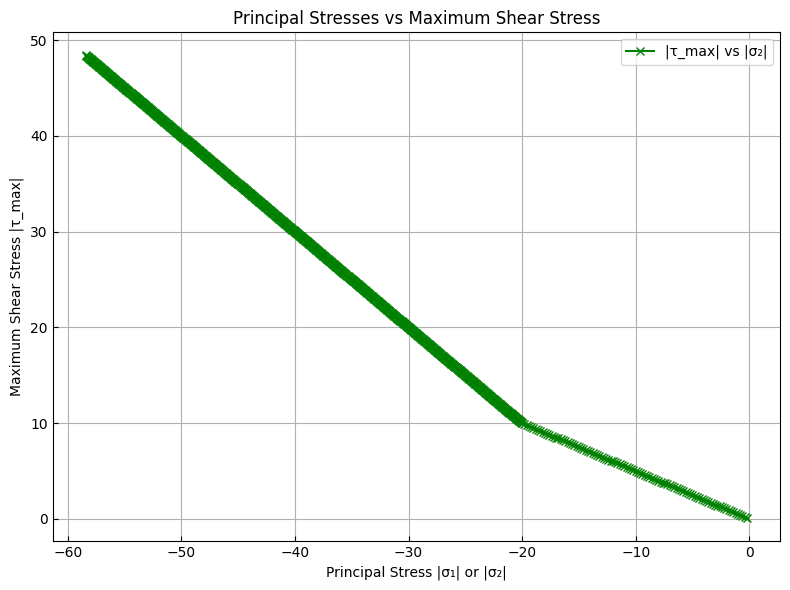

In [215]:
plot_principal_vs_max_shear("astress1.out")

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_principal_vs_max_shear_with_dp(stress_file, cohesion, friction_angle_deg):
    """
    Plots |σ₁| and |σ₂| vs |τ_max| with Drucker–Prager failure envelope.

    Parameters:
    stress_file (str): Path to stress data file.
    cohesion (float): Material cohesion (same units as stress data).
    friction_angle_deg (float): Friction angle φ in degrees.
    """
    # Load stress data
    df = pd.read_csv(stress_file, delim_whitespace=True, header=None)
    sigma_x = df[1]
    sigma_y = df[2]
    tau_xy = df[3]

    # Compute principal stresses and max shear
    avg_sigma = (sigma_x + sigma_y) / 2
    radius = np.sqrt(((sigma_x - sigma_y) / 2)**2 + tau_xy**2)
    sigma_1 = avg_sigma + radius
    sigma_2 = avg_sigma - radius
    tau_max = radius

    # Absolute values for plotting
    sigma_1_abs = sigma_1.abs()
    sigma_2_abs = sigma_2.abs()
    tau_max_abs = tau_max.abs()

    # Convert friction angle to radians
    phi_rad = np.radians(friction_angle_deg)

    # Drucker–Prager constants (inscribed cone version)
    A = (6 * cohesion * np.cos(phi_rad)) / (np.sqrt(3) * (3 - np.sin(phi_rad)))
    B = (2 * np.sin(phi_rad)) / (np.sqrt(3) * (3 - np.sin(phi_rad)))

    # Build Drucker–Prager line
    sigma_range = np.linspace(0, max(sigma_1_abs.max(), sigma_2_abs.max()) * 1.1, 100)
    tau_dp = A + B * sigma_range

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(sigma_1_abs, tau_max_abs, 'o', label='|τ_max| vs |σ₁|', color='blue')
    plt.plot(sigma_2_abs, tau_max_abs, 'x', label='|τ_max| vs |σ₂|', color='green')
    plt.plot(sigma_range, tau_dp, '--', color='red', label='Drucker–Prager Failure Envelope')
    plt.xlabel("Principal Stress |σ₁| or |σ₂|")
    plt.ylabel("Maximum Shear Stress |τ_max|")
    plt.title("Principal Stress vs τ_max with Drucker–Prager Envelope")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


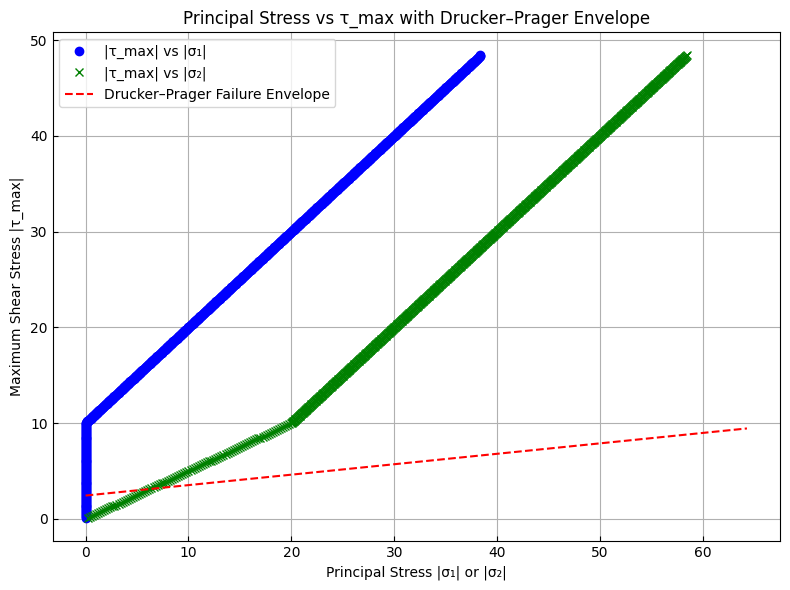

In [217]:
# Example: cohesion = 10 MPa, friction angle = 30°
plot_principal_vs_max_shear_with_dp("astress1.out", cohesion=2, friction_angle_deg=15)


In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_with_failure_envelopes(stress_file, cohesion, friction_angle_deg):
    """
    Plots principal stresses vs τ_max, superimposing both Drucker–Prager
    and Mohr–Coulomb failure criteria.

    Parameters:
    stress_file (str): Path to stress data file.
    cohesion (float): Cohesion (same unit as stress).
    friction_angle_deg (float): Friction angle φ in degrees.
    """
    df = pd.read_csv(stress_file, delim_whitespace=True, header=None)
    sigma_x = df[1]
    sigma_y = df[2]
    tau_xy = df[3]

    avg_sigma = (sigma_x + sigma_y) / 2
    radius = np.sqrt(((sigma_x - sigma_y) / 2)**2 + tau_xy**2)
    sigma_1 = avg_sigma + radius
    sigma_2 = avg_sigma - radius
    tau_max = radius

    sigma_1_abs = sigma_1.abs()
    sigma_2_abs = sigma_2.abs()
    tau_max_abs = tau_max.abs()

    phi_rad = np.radians(friction_angle_deg)
    tan_phi = np.tan(phi_rad)

    A_dp = (6 * cohesion * np.cos(phi_rad)) / (np.sqrt(3) * (3 - np.sin(phi_rad)))
    B_dp = (2 * np.sin(phi_rad)) / (np.sqrt(3) * (3 - np.sin(phi_rad)))

    sigma_range = np.linspace(0, max(sigma_1_abs.max(), sigma_2_abs.max()) * 1.2, 200)
    tau_dp = A_dp + B_dp * sigma_range
    tau_mc = cohesion + sigma_range * tan_phi

    plt.figure(figsize=(9, 6))  # Stretch the plot wider to match your image
    #plt.plot(sigma_1_abs, tau_max_abs, 'o', label='|τ_max| vs |σ₁|', color='blue')
    plt.plot(sigma_2_abs, tau_max_abs, 'x', label='|τ_max| vs |σ₂|', color='green')
    #plt.plot(sigma_range, tau_dp, '--', color='red', label='Drucker–Prager Envelope')
    plt.plot(sigma_range, tau_mc, '-', color='black', label='Mohr–Coulomb Envelope')

    plt.xlabel("Principal Stress |σ₁| or |σ₂|")
    plt.ylabel("Maximum Shear Stress |τ_max|")
    plt.title("Failure Criteria: Mohr–Coulomb vs Drucker–Prager")
    plt.grid(True)
    plt.legend()
    # DO NOT set aspect ratio equal — keep distortion like in original
    plt.tight_layout()
    plt.show()


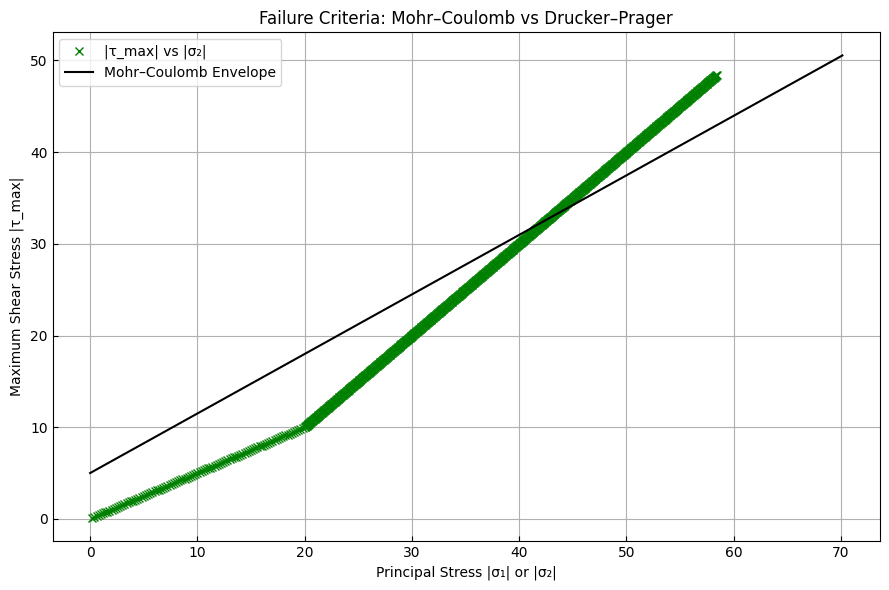

In [219]:
plot_with_failure_envelopes("astress1.out", cohesion=5, friction_angle_deg=33)

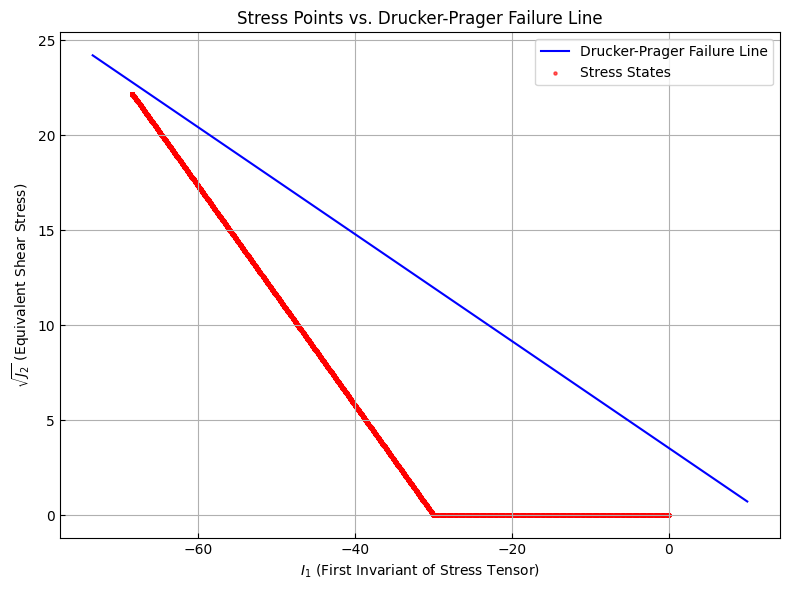

In [221]:
# drucker_prager_with_xarray.py

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Extract arrays from xarray (shape: [time, GaussPoints])
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1).values  # shape: (1001, 8)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1).values
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1).values

# Step 2: Compute I1 = σ11 + σ22 + σ33
I1_vals = sigma11 + sigma22 + sigma33  # shape: (1001, 8)

# Step 3: Compute deviatoric stress s = σ - (1/3) I1
mean_stress = I1_vals / 3
s11 = sigma11 - mean_stress
s22 = sigma22 - mean_stress
s33 = sigma33 - mean_stress

# Step 4: Compute sqrt(J2) = sqrt(0.5 * (s11² + s22² + s33²))
J2_vals = 0.5 * (s11**2 + s22**2 + s33**2)
sqrt_J2_vals = np.sqrt(J2_vals)

# Step 5: Flatten for scatter plotting
I1_flat = I1_vals.flatten()
sqrt_J2_flat = sqrt_J2_vals.flatten()

# Step 6: Drucker-Prager failure line
rho = 0.398
sigma_Y = 5
I1_line = np.linspace(np.min(I1_flat)-5, np.max(I1_flat)+10, 500)
dp_line = - (1 / np.sqrt(2)) * rho * I1_line + (1 / np.sqrt(2)) * sigma_Y

# Step 7: Plot
plt.figure(figsize=(8, 6))
plt.plot(I1_line, dp_line, label='Drucker-Prager Failure Line', color='blue')
plt.scatter(I1_flat, sqrt_J2_flat, s=5, color='red', alpha=0.6, label='Stress States')

plt.xlabel(r'$I_1$ (First Invariant of Stress Tensor)')
plt.ylabel(r'$\sqrt{J_2}$ (Equivalent Shear Stress)')
plt.title('Stress Points vs. Drucker-Prager Failure Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
